In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_parquet("df_tokens.parquet")
print(df.columns.tolist())

['NODE_ID', 'PBSH', 'NODE_CLSS_02', 'NODE_TTLE', 'NODE_TTLE_EN', 'ABST_KR', 'ABST_EN', 'KYWD', 'ko_text', 'en_text', 'ko_tokens', 'en_tokens', 'merged_tokens_dedup']


In [3]:
def debug_rows_full(df: pd.DataFrame, n: int = 10, seed: int = 42):
    # 모든 컬럼에 대해 row 단위 디버그 출력
    # pandas 출력 옵션: 잘림 방지
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 0)

    # 샘플링
    view = df.sample(n=min(n, len(df)), random_state=seed)

    print("\n[TOKEN DEBUG SAMPLE]")

    for _, row in view.iterrows():
        print("=" * 110)

        for col in df.columns:
            val = row[col]

            print(f"[{col}]")
            if isinstance(val, list):
                print(val)
            else:
                print(val)

        print()  # row 간 공백

debug_rows_full(df, n=8, seed=900)


[TOKEN DEBUG SAMPLE]
[NODE_ID]
NODE10673785
[PBSH]
202112
[NODE_CLSS_02]
컴퓨터학
[NODE_TTLE]
RDID-GAN: Reconstructing a De-identified Image Dataset to Generate Effective Learning Data
[NODE_TTLE_EN]
RDID-GAN: 비식별화 이미지 데이터 복원을 통한 효과적인 학습데이터 생성
[ABST_KR]
최근 여러 사회 문제들을 예방 및 신속하게 대처하기 위해 CCTV가 설치되고 있고 인공지능을 활용해 이를 효과적으로 처리하는 방안이 연구되고 있다. 하지만, CCTV에서 수집한 데이터는 개인정보 침해의 우려가 있어 비식별화 작업 없이는 자유롭게 사회문제 해결을 위한 모델을 연구하는데 사용할 수 없다. 따라서, 본 논문에서는 RDID-GAN을 제안하여 비식별화된 사람의 얼굴을 임의로 복원하여 개인정보 침해의 우려를 줄이고 네트워크 학습에도 부정적인 영향을 주지 않는 효과적인 데이터셋 제작 방안을 제안한다. RDID-GAN은 attention module을 활용해 비식별화된 부분에 집중하여 합당한 결과를 생성할 수 있도록 하였다. 우리는 실험을 통해 해당 모델과 기존의 제안된 image-to-image 변환 모델을 정성적 및 정량적으로 비교하였다.
[ABST_EN]
Recently, CCTVs have been installed to prevent or handle various social problems, and there are many efforts to develop visual surveillance systems based on deep neural networks. However, the datasets collected from CCTVs are inappropriate to train models due to privacy issues. Therefore, in this paper, we proposed 

df_tokens.parquet에서 저장한 PBSH == YYYYMM

분리해서 YYYY는 year 필드, MM은 month 필드로 저장해서 나눔

In [4]:
# PBSH를 문자열로 보정 (혹시 숫자로 들어온 경우 대비)
df["PBSH"] = df["PBSH"].astype(str).str.strip()

# year, month 컬럼 생성
df["year"] = df["PBSH"].str.slice(0, 4).astype("Int64")
df["month"] = df["PBSH"].str.slice(4, 6).astype("Int64")

print(df[["PBSH", "year", "month"]].head())

print("\n 연도별:")
print(df["year"].value_counts().sort_index())

print("\n 월별(추가):")
print(df["month"].value_counts().sort_index())

     PBSH  year  month
0  202106  2021      6
1  202106  2021      6
2  202106  2021      6
3  202106  2021      6
4  202106  2021      6

 연도별:
year
2021    12435
2022    12333
2023    12203
2024    12658
2025    11078
Name: count, dtype: Int64

 월별(추가):
month
1     3569
2     5406
3     4842
4     5247
5     3359
6     6710
7     3469
8     5318
9     5172
10    5662
11    4171
12    7782
Name: count, dtype: Int64


In [5]:
print(df.columns.tolist())

['NODE_ID', 'PBSH', 'NODE_CLSS_02', 'NODE_TTLE', 'NODE_TTLE_EN', 'ABST_KR', 'ABST_EN', 'KYWD', 'ko_text', 'en_text', 'ko_tokens', 'en_tokens', 'merged_tokens_dedup', 'year', 'month']


In [6]:
GENAI_ANCHORS = {
    "genai",
    "generative-ai",
    "생성형-ai",
    "생성형-인공지능",
    "gpt",
    "language-generation-model",
    "chat-gpt",
    "multimodal-model",
    "llm",
    "large-language-model",
    "gemini",
    "copilot",
    "claude",
    "llama",
    "hyperclova-x",
    "deepseek",
    "midjourney",
    "dall-e",
    "stable-diffusion",
}

def is_genai_doc(tokens):
    # NaN/None = False
    if tokens is None:
        return False
    if isinstance(tokens, float) and np.isnan(tokens):
        return False

    # list뿐 아니라 tuple/ndarray 등도 허용 ..
    if isinstance(tokens, (list, tuple, set, np.ndarray)):
        return any(t in GENAI_ANCHORS for t in tokens)

    # 혹시 문자열로 저장된 경우(예: "['a','b']") 그냥 False 처리
    return False

df["is_genai"] = df["merged_tokens_dedup"].apply(is_genai_doc)

In [7]:
def debug_genai_rows(df: pd.DataFrame, n: int = 10, seed: int = 42, show_fields=None):
    # pandas 출력 옵션 (잘림 방지)
    pd.set_option("display.max_colwidth", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 0)

    # 기본 확인 필드 (필요 시 수정 가능)
    if show_fields is None:
        show_fields = [
            "NODE_ID",
            "NODE_TTLE",
            "NODE_TTLE_EN",
            "ABST_KR",
            "ABST_EN",
            "KYWD",
            "merged_tokens_dedup",
            "is_genai",
        ]

    # GENAI 문서만 필터
    df_genai = df[df["is_genai"] == True]

    if len(df_genai) == 0:
        print("[DEBUG] is_genai == True 인 행이 없습니다.")
        return

    view = df_genai.sample(
        n=min(n, len(df_genai)),
        random_state=seed
    )

    print("\n[GENAI DOC DEBUG SAMPLE]")

    for _, row in view.iterrows():
        print("=" * 110)

        for col in show_fields:
            if col not in df.columns:
                continue

            val = row[col]
            print(f"[{col}]")

            if isinstance(val, (list, tuple, set)):
                print(list(val))
            else:
                print(val)

        print()  # row 간 공백

debug_genai_rows(df, n=3, seed=200)


[GENAI DOC DEBUG SAMPLE]
[NODE_ID]
NODE11751444
[NODE_TTLE]
Transformer 기반 LLM의 학습을 이용한 112 허위오인신고분류·예측모델 개발
[NODE_TTLE_EN]
Development of a False Alarm Classification and Prediction Model Using Transformer-Based Large Language Model
[ABST_KR]
112 긴급신고 시스템은 국민 안전을 위한 경찰의 최전선으로, 신속한 출동 및 사건처리가 무엇보다도 중요하다. 허위오인신고는 경찰력이 낭비될뿐 아니라 진정으로 도움을 필요로 하는 상황에 대응하기가 어려워진다는 점에서 그 문제가 크다. 최근들어 증가하고 있는 허위오인신고에 대응하기 위하여 본 연구자는 딥러닝을 기반으로한 112 허위오인신고 분류·예측모델을 제안한다. 본 모델은 112상황실 접수요원이 요약한 신고내용 텍스트를 입력받아 해당 신고의 허위오인여부를 결정하게 된다. 악의적 허위신고와 오인신고중 후자는 신고접수자 입장에서 표면적으로 알아채기가 불가능에 가깝다. 이로 인해 연구자는 허위오인신고 전체 데이터와 악의적인 허위신고만을 담은 데이터를 나누어 실험하였다. 트랜스포머 구조를 가진 BERT, KoBERT,ELECTRA, KoELECTRA, RoBERTa 5가지 모델에 대하여 동일한 하이퍼파라미터로 모델 훈련을 진행했다. 본 연구는 자연어처리와 LLM을 이용하여 경찰의 실제 치안업무에 대해 문제해결적 접근을 수행했다는 점에 의의가 있다. 본 연구의 결과가 악의적인 허위신고를 빠르게 식별하고 경찰이 의사결정을 지원하는데에 도움이 될 것으로 기대한다.
[ABST_EN]
The 112 emergency reporting system is the police"s front line for public safety, and rapid dispatch and incident handling are of the utmost importa

In [8]:
hits = (
    df.explode("merged_tokens_dedup")
      .loc[lambda x: x["merged_tokens_dedup"].isin(GENAI_ANCHORS), ["merged_tokens_dedup"]]
)

print("anchor hits:", len(hits))
print(hits["merged_tokens_dedup"].value_counts().head(30))

anchor hits: 1471
merged_tokens_dedup
llm                          324
large-language-model         284
generative-ai                270
chat-gpt                     145
gpt                          140
생성형-ai                        83
생성형-인공지능                      59
llama                         33
stable-diffusion              28
midjourney                    24
multimodal-model              17
gemini                        15
dall-e                        15
copilot                       11
genai                          6
deepseek                       6
claude                         5
language-generation-model      4
hyperclova-x                   2
Name: count, dtype: int64


In [9]:
print(df.columns.tolist())

['NODE_ID', 'PBSH', 'NODE_CLSS_02', 'NODE_TTLE', 'NODE_TTLE_EN', 'ABST_KR', 'ABST_EN', 'KYWD', 'ko_text', 'en_text', 'ko_tokens', 'en_tokens', 'merged_tokens_dedup', 'year', 'month', 'is_genai']


# 연도별 빈도 및 시각화

In [10]:
!apt-get -qq -y install fonts-nanum

Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 나눔고딕 -> 적용이 잘 안돼서 한글 들어가는 곳마다 fontproperties=font_prop 넣어줌 ..
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

In [12]:
# 연도별 전체 논문 수
yearly_total = (
    df.groupby("year")
      .agg(전체_논문수=("NODE_ID", "count"))
      .reset_index()
)

# 연도별 생성형 AI 논문 수
yearly_genai = (
    df[df["is_genai"]]
    .groupby("year")
    .agg(생성형AI_논문수=("NODE_ID", "count"))
    .reset_index()
)

# 병합하고 비율 계산
yearly_ratio = (
    yearly_total
    .merge(yearly_genai, on="year", how="left")
    .fillna({"생성형AI_논문수": 0})
)

yearly_ratio["생성형AI_논문비율"] = (
    yearly_ratio["생성형AI_논문수"] / yearly_ratio["전체_논문수"]
)

yearly_ratio

,year,전체_논문수,생성형AI_논문수,생성형AI_논문비율
0,2021,12435,4,0.000322
1,2022,12333,11,0.000892
2,2023,12203,85,0.006966
3,2024,12658,294,0.023226
4,2025,11078,423,0.038184


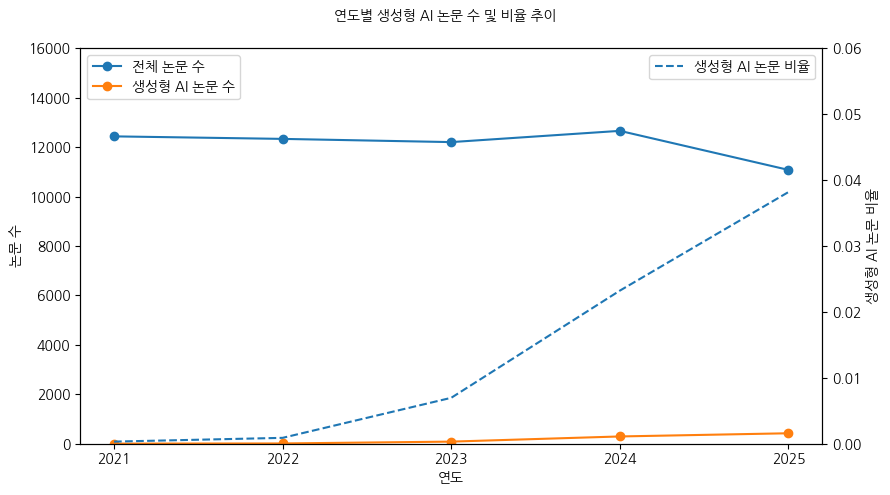

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 5))
years = sorted(yearly_ratio["year"].unique())
ax1.set_xticks(years)
ax1.set_xticklabels([str(y) for y in years], fontproperties=font_prop)

# 논문 수 (좌측 축)
ax1.plot(
    yearly_ratio["year"],
    yearly_ratio["전체_논문수"],
    marker="o",
    label="전체 논문 수"
)
ax1.plot(
    yearly_ratio["year"],
    yearly_ratio["생성형AI_논문수"],
    marker="o",
    label="생성형 AI 논문 수"
)

ax1.set_xlabel("연도", fontproperties=font_prop)
ax1.set_ylabel("논문 수", fontproperties=font_prop)
ax1.set_ylim(0, 16000)

# 좌측 범례 (한글)
ax1.legend(loc="upper left", prop=font_prop)

# 틱 라벨 폰트
for tick in ax1.get_xticklabels():
    tick.set_fontproperties(font_prop)
for tick in ax1.get_yticklabels():
    tick.set_fontproperties(font_prop)

# 비율 (우측 축)
ax2 = ax1.twinx()
ax2.plot(
    yearly_ratio["year"],
    yearly_ratio["생성형AI_논문비율"],
    linestyle="--",
    label="생성형 AI 논문 비율"
)

ax2.set_ylabel("생성형 AI 논문 비율", fontproperties=font_prop)
ax2.set_ylim(0, 0.06)

# 우측 축 틱 폰트
for tick in ax2.get_yticklabels():
    tick.set_fontproperties(font_prop)

# 우측 범례
ax2.legend(loc="upper right", prop=font_prop)

# 전체 제목
fig.suptitle(
    "연도별 생성형 AI 논문 수 및 비율 추이",
    fontproperties=font_prop
)

fig.tight_layout()
plt.show()

In [14]:
clss_genai_count = (
    df[df["is_genai"]]
    .groupby("NODE_CLSS_02")
    .agg(생성형AI_논문수=("NODE_ID", "count"))
    .sort_values("생성형AI_논문수", ascending=False)
    .reset_index()
)

clss_genai_count.head(10)

,NODE_CLSS_02,생성형AI_논문수
0,전기전자공학,333
1,컴퓨터학,318
2,산업공학,48
3,공학 일반,44
4,건축공학,29
5,기계공학,25
6,기타 공학,20


In [15]:
MAX_PER_CLASS = 5

genai_df = df[df["is_genai"]].copy()

for clss, g in genai_df.groupby("NODE_CLSS_02"):
    print("=" * 80)
    print(f"[중분류] {clss}  (생성형 AI 논문 수: {len(g)})")
    print("-" * 80)

    sample = g.head(MAX_PER_CLASS)

    for _, row in sample.iterrows():
        title = row["NODE_TTLE"]
        if not isinstance(title, str) or title.strip() == "":
            title = row.get("NODE_TTLE_EN", "")

        print(f"- NODE_ID: {row['NODE_ID']}")
        print(f"  제목   : {title}")

    if len(g) > MAX_PER_CLASS:
        print(f"  ... (이 외 {len(g) - MAX_PER_CLASS}편 생략)")

[중분류] 건축공학  (생성형 AI 논문 수: 29)
--------------------------------------------------------------------------------
- NODE_ID: NODE12341949
  제목   : Applications of AI Large Language Models in Citizen Participatory Urban Planning : Using GPT-4o and Prompt Engineering
- NODE_ID: NODE12336324
  제목   : BIM-Based Visualization of Greenhouse Gas Emissions Using Generative Artificial Intelligence and Life Cycle Assessment
- NODE_ID: NODE12425051
  제목   : LLM별 프롬프트에 따른 AI 건축 이미지 생성 결과 비교 연구
- NODE_ID: NODE11218715
  제목   : 인공지능 ChatGPT와의 대화에서 엿본 미래의 희망
- NODE_ID: NODE12270231
  제목   : 멀티모달 대규모 언어모델과 기계학습을 활용한 도시 가로 경관 쇠퇴 영향요인 분석
  ... (이 외 24편 생략)
[중분류] 공학 일반  (생성형 AI 논문 수: 44)
--------------------------------------------------------------------------------
- NODE_ID: NODE11933396
  제목   : 한국어 대규모 언어 모델의 양자화 성능에 대한 비교 연구
- NODE_ID: NODE11954394
  제목   : LDA 토픽 모델링 분석을 통한 챗GPT 활용에 대한 탐색적 연구 -챗GPT와 교육을 중심으로-
- NODE_ID: NODE12119714
  제목   : 대학생의 ChatGPT 인식, 경험 및 사용의도에 대한 영향 요인
- NODE_ID: NODE1211971

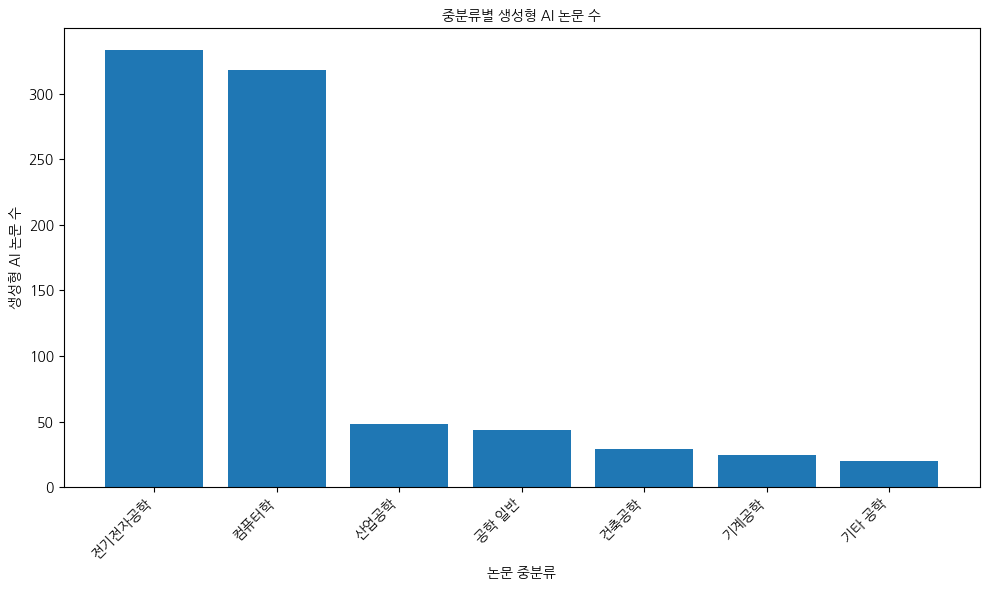

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    clss_genai_count["NODE_CLSS_02"],
    clss_genai_count["생성형AI_논문수"]
)

ax.set_xlabel("논문 중분류", fontproperties=font_prop)
ax.set_ylabel("생성형 AI 논문 수", fontproperties=font_prop)
ax.set_title("중분류별 생성형 AI 논문 수", fontproperties=font_prop)

plt.xticks(rotation=45, ha="right")

for tick in ax.get_xticklabels():
    tick.set_fontproperties(font_prop)
for tick in ax.get_yticklabels():
    tick.set_fontproperties(font_prop)

plt.tight_layout()
plt.show()

2021-2022 평균 논문 수와 2023-2025 평균 논문 수

연평균 증가율 비교

In [17]:
early_years = [2021, 2022]
late_years  = [2023, 2024, 2025]

# 연도별 생성형AI 논문 수가 yearly_ratio에 들어있으므로 그대로 사용
count_early = yearly_ratio.loc[yearly_ratio["year"].isin(early_years), "생성형AI_논문수"].sum()
count_late  = yearly_ratio.loc[yearly_ratio["year"].isin(late_years),  "생성형AI_논문수"].sum()

avg_early = count_early / len(early_years)
avg_late  = count_late  / len(late_years)

growth_rate = (avg_late - avg_early) / avg_early * 100 if avg_early != 0 else float("nan")

print(f"[GENAI] 전기(2021-2022) 합계: {count_early:.0f}, 연평균: {avg_early:.2f}편/년")
print(f"[GENAI] 후기(2023-2025) 합계: {count_late:.0f}, 연평균: {avg_late:.2f}편/년")
print(f"[GENAI] 증가율: {growth_rate:.1f}%")

[GENAI] 전기(2021-2022) 합계: 15, 연평균: 7.50편/년
[GENAI] 후기(2023-2025) 합계: 802, 연평균: 267.33편/년
[GENAI] 증가율: 3464.4%


In [18]:
avg_ratio_early = yearly_ratio.loc[yearly_ratio["year"].isin(early_years), "생성형AI_논문비율"].mean()
avg_ratio_late  = yearly_ratio.loc[yearly_ratio["year"].isin(late_years),  "생성형AI_논문비율"].mean()

delta_pp = (avg_ratio_late - avg_ratio_early) * 100  # 퍼센트포인트 변화

print(f"[GENAI] 전기 평균 비율: {avg_ratio_early*100:.2f}%")
print(f"[GENAI] 후기 평균 비율: {avg_ratio_late*100:.2f}%")
print(f"[GENAI] 비율 변화: {delta_pp:+.2f}%p")


[GENAI] 전기 평균 비율: 0.06%
[GENAI] 후기 평균 비율: 2.28%
[GENAI] 비율 변화: +2.22%p


# tf-idf

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

from itertools import combinations
from collections import Counter, defaultdict

import networkx as nx
import matplotlib.pyplot as plt

In [20]:
# 생성형 AI 논문 수 기준 상위 4개 중분류
top4_classes = (
    df[df["is_genai"]]
    .groupby("NODE_CLSS_02")["NODE_ID"]
    .count()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

top4_classes

['전기전자공학', '컴퓨터학', '산업공학', '공학 일반']

In [21]:
# 확인용으로 전기전자 생성형 ai 논문들 출력
tmp = df[(df["NODE_CLSS_02"]=="전기전자공학") & (df["is_genai"])][["NODE_ID","merged_tokens_dedup"]].head(5)
display(tmp)
print(tmp["merged_tokens_dedup"].apply(type).value_counts())

,NODE_ID,merged_tokens_dedup
421,NODE11933315,"[검색, 증강, 생성, 거대언어, 모델, 대학, 학습관리, 시스템, 학생, 질의응답, 챗봇, lms, 학업, 전반적, 과정, 관리, 지원, 교육, 운영, 중요 역할, 이때, 학습, 활동, 상담원, 질문, 수기, 답변, 비효율, 자연어 처리, llm, 발전, 인공지능, 활발, 질의, 자동, 제공, 축적, 채팅, 데이터, 임베, 데이터셋 구축, 이후, 입력, 연관성, 추출, 신뢰성, 다양, 의도, 이해, 명확, 확인, learning management system, large language model, chatbot, retrieval-augmented generation, pre-trained language model, student, service, learning, management, system, university, retrieval-augmented, generation-based, large-language-model, lm, play crucial, role, manage, support, educational, activity, context, operate, within, aid, however, exist, les, efficient, relie, human, counselor, manually, respond, inquirie, recent, development, natural language, processing, grow, research, artificial, intelligence-based, propose, automatically, question, first, construct, retrieval, ...]"
422,NODE11933316,"[생성형 인공지능, 문화예술, 창작, 창의성, ai, generative, 문화, 예술, 탐구, 인간, 협업, 영향, 규명, 기준, 차이, 본질, 심도, 논의, 제공, 전문가, 심층 인터뷰, 평가지표, 대표적, 미술, 작품, llm, 텍스트, 단계적, gpt, 프롬프트, 유형, 유용성, 증진, 반면, 다양성, 축소, 가능성, 확인, 발전, 정립, 중요, 기여 기대, generative ai, cultural arts, creativity, collaboration, evaluation, cultural, art, creation, artificial intelligence, explore, component, generative-ai, analyzed, method, evaluate, aim, impact, human, analyze, difference, criterion, provide, in-depth, discussion, nature, interview, expert, discuss, experiment, text, analysis, conduct, step, five, representative, work, use, different, prompt, type, find, enhance, usefulness, reduce, diversity, expect, make, significant, contribution, establishment, new, standard, particularly, technology, continue, evolve]"
425,NODE11933319,"[생성형 ai, 레벨, 디자인, 생성, 게임, 환경, 자동화, 시스템, 개발, 가능성, 탐구, 스테이, 디퓨전, 다양, 데이터, 리얼, 타임, 엔진, 절차적, 자동, 경로, 탐색, 알고리즘, 실제, 플레이, 입증, 시간 단축, 비용 절감, 효과적, 확인, 시각적, 풍부, 구축, 플레이어, 경험, 향상, 기여, 개발자들, 도구, 방법론, 제공, 창의적, 효율적, 향후, 범위, 확장, 장르, 필요, generative ai, game, level design, procedural generation, environment design, level, design, generation, generative-ai, explore, development, potential, automated, system, environment, research, employ, stable-diffusion, generate, diverse, data, use, procedurally, create, within, real-time, engine, generated, validate, pathfinding, algorithm, demonstrate, playability, result, indicate, effectively, reduce, time, cost, overcome limitation, traditional, manual, processe, furthermore, procedural, validation, allow, rapid, construction, visually, rich, enhance, ...]"
431,NODE11933323,"[재난, 경보, 시스템, 생성, ai, 프레임워크, text, to, cinemagraph, 텍스트, 이미지, 광학, 흐름, 카메라, 움직임, 애니메이션, 결합, 동적, 시각, 현재, video, 복잡, 자원, 소모, 접근, 간단, 시나리오, 특정, 도메인, 설계, 실제, 추출, 메타데이터, llm, model, fine, tuning, metadata, generator, prompt, diffusion, based, image, generative, 애니메이션화, 생생, 묘사, 취약계층, 명확, 접근성, 향상, deep generative ai, text-to-3d cinemagraph, text-to-image, t2i, fine-tuning, large language model, text-to-3d, cinemagraphs, generation, visual, content, disaster, alert, generative-ai, framework, propose novel, call, enhance, communication, technology, use, combination, along, animation, technique, optical, flow, camera, movement, create, dynamic, unlike, current, text-to-video, complex, resource-intensive, approach, simple, faster, adaptable, specifically, design, scenario, fine-tuned, extract, real-world, serve, generate, diffusion-based, ...]"
442,NODE11933338,"[키워드, 도메인, 속성, 고품질, 정제기법, 추출, 내용, 요약, 관련, 문헌, 검색, 중요, 도구, 발전, 전문화, 문서, 범위, 깊이, 확장, 핵심, 주제, 식별, 필수적, 전체적, 맥락, 복잡, 이해, 전문, 지식, 이용자들, 정확성, 관련성, 판단, llm, large language, model, 프롬프트, 접근, 속성값, 정제방법, 부연, 설명, 추가, 중요성, 의도, 역할, 구성측면, 정제과정, 작용, 파악, 효과, keyword extraction, attribute value, prompt engineering, high-quality, keyword, refinement, technique, consider, domain, attribute, extraction, important, tool, summarize, research, content, search, related, literature, technological, advancement, specialization, expand, scope, depth, document, become, crucial, identify, core, theme, however, traditional, method, limitation, fully, understand, overall, c

merged_tokens_dedup
<class 'numpy.ndarray'>    5
Name: count, dtype: int64


In [22]:
# 앵커 유니그램 제거해서 앵커 집합과는 상관 없는 실제 키워드 뽑고 싶음
ANCHOR_UNIGRAM_STOP = {
    "ai", "artificial", "intelligence",
    "model", "models",
    "language", "large", "generative", "generation",
    "llm", "gpt", "chat", "based",
    "인공지능", "모델", "언어", "생성", "생성형",
    # 앵커 유니그램 아니어도 불용어 추가(공통)
    "data", "result", "데이터", "결과", "propose", "분야", "다양"
}

ANCHOR_PHRASE_STOP = {
    "chat-gpt",
    "generative-ai",
    "genai",
    "large-language-model",
    "language-generation-model",
    "multi-modal",
    "multimodal-model",
    "gemini", "copilot", "claude", "deepseek", "llama", "hyperclova-x",
    "dall-e", "midjourney", "stable-diffusion",
    "생성형-ai", "생성형-인공지능", "생성형 ai", "generative ai", "large language"
}

SEP = "|||"

def normalize_token_for_tfidf(t: str) -> str:
    t = (t or "").strip().lower()
    # 중점 통일
    t = t.replace("·", "-").replace("\u00B7", "-")
    # 토큰 내부 공백은 유지(SEP로만 분리할 거라 괜찮음)
    return t

def doc_from_tokens(tokens):
    if isinstance(tokens, np.ndarray): # ndarray ..
        tokens = tokens.tolist()
    # list/tuple은 그대로, 그 외는 빈 문서 처리
    if not isinstance(tokens, (list, tuple)):
        return ""

    out = []
    for t in tokens:
        if not isinstance(t, str):
            continue
        tn = normalize_token_for_tfidf(t)
        if not tn:
            continue

        # 유니그램 stop
        if tn in ANCHOR_UNIGRAM_STOP:
            continue
        if tn in ANCHOR_PHRASE_STOP:
            continue

        out.append(tn)

    return SEP.join(out)

def sep_tokenizer(s):
    return s.split(SEP) if s else []

In [42]:
TOP_K = 30

tfidf_results = {}

for clss in top4_classes:
    sub_df = df[
        (df["NODE_CLSS_02"] == clss) &
        (df["is_genai"])
    ].copy()

    # 문서 생성
    docs = sub_df["merged_tokens_dedup"].apply(doc_from_tokens)

    vectorizer = TfidfVectorizer( # 토큰 내 공백포함 -> 공백으로 토큰이 분리되지 않게 None하고 False
        tokenizer=sep_tokenizer,
        preprocessor=None,
        lowercase=False,   # 이미 lower 처리하므로 중복 방지
        token_pattern=None # 기본 토큰패턴 비활성화
    )

    X = vectorizer.fit_transform(docs)

    tfidf_mean = X.mean(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    tfidf_df = (
        pd.DataFrame({
            "keyword": vocab,
            "tfidf": tfidf_mean
        })
        .sort_values("tfidf", ascending=False)
        .head(TOP_K)
        .reset_index(drop=True)
    )

    tfidf_results[clss] = tfidf_df

for clss, kw_df in tfidf_results.items():
    print("=" * 80)
    print(f"[중분류] {clss} - 생성형 AI TF-IDF 상위 20 키워드")
    print("=" * 80)
    display(kw_df)

[중분류] 전기전자공학 - 생성형 AI TF-IDF 상위 20 키워드


,keyword,tfidf
0,system,0.016689
1,performance,0.016525
2,provide,0.015922
3,enhance,0.015120
4,improve,0.015039
5,technology,0.014912
6,research,0.014825
7,development,0.014279
8,however,0.014187
9,show,0.014146


[중분류] 컴퓨터학 - 생성형 AI TF-IDF 상위 20 키워드


,keyword,tfidf
0,technology,0.014760
1,generate,0.014323
2,성능,0.014320
3,학습,0.014220
4,research,0.013767
5,enhance,0.013707
6,확인,0.013453
7,performance,0.013230
8,analyze,0.013173
9,however,0.013061


[중분류] 산업공학 - 생성형 AI TF-IDF 상위 20 키워드


,keyword,tfidf
0,enhance,0.020811
1,analysis,0.019260
2,however,0.019075
3,improve,0.018377
4,approach,0.018315
5,demonstrate,0.018210
6,research,0.017570
7,analyze,0.017477
8,technology,0.017423
9,application,0.017252


[중분류] 공학 일반 - 생성형 AI TF-IDF 상위 20 키워드


,keyword,tfidf
0,show,0.021211
1,analysis,0.021190
2,technology,0.020814
3,analyze,0.020549
4,performance,0.019165
5,가능성,0.019103
6,확인,0.019094
7,개발,0.018787
8,artificial intelligence,0.018512
9,학습,0.017821


In [43]:
TOP_K_ALL = 50

# 생성형 AI 논문만
genai_df = df[df["is_genai"]].copy()
docs_all = genai_df["merged_tokens_dedup"].apply(doc_from_tokens)

# TF-IDF 벡터라이저 (똑같이 None, False)
vectorizer_all = TfidfVectorizer(
    tokenizer=sep_tokenizer,
    preprocessor=None,
    lowercase=False,
    token_pattern=None,
    min_df=2,
    max_df=0.8
)

X_all = vectorizer_all.fit_transform(docs_all)

tfidf_mean_all = X_all.mean(axis=0).A1
vocab_all = vectorizer_all.get_feature_names_out()

tfidf_all_df = (
    pd.DataFrame({
        "keyword": vocab_all,
        "tfidf": tfidf_mean_all
    })
    .sort_values("tfidf", ascending=False)
    .head(TOP_K_ALL)
    .reset_index(drop=True)
)

print("=" * 80)
print(f"[전체] 생성형 AI TF-IDF 상위 {TOP_K_ALL} 키워드")
print("=" * 80)
display(tfidf_all_df)

[전체] 생성형 AI TF-IDF 상위 50 키워드


,keyword,tfidf
0,research,0.015678
1,performance,0.015522
2,technology,0.015495
3,system,0.015177
4,enhance,0.015160
5,generate,0.014746
6,analyze,0.014645
7,provide,0.014621
8,improve,0.014413
9,design,0.014244


In [55]:
PERIODS = {
    "2021-2022": (2021, 2022),
    "2023-2025": (2023, 2025),
}

전기/후기를 비교하려면 IDF 기준 동일해야 함.

GenAI 문서 전체에서 vectorizer를 1번

-> 각 문서의 토큰 리스트(merged_tokens_dedup)를 TF-IDF 입력용 문자열 변환

-> TfidfVectorizer.fit

In [56]:
def fit_global_tfidf_vectorizer(df_src: pd.DataFrame,
                                year_from: int, year_to: int,
                                min_df: int = 2,
                                max_df: float = 0.8): # 전/후 비교 가능한 TF-IDF를 위해 year_from~year_to 구간의 GenAI 문서 전체로 vectorizer"
    sub_all = df_src[
        (df_src["is_genai"]) &
        (df_src["year"] >= year_from) &
        (df_src["year"] <= year_to)
    ].copy()

    docs_all = sub_all["merged_tokens_dedup"].apply(doc_from_tokens)

    vectorizer = TfidfVectorizer(
        tokenizer=sep_tokenizer,
        preprocessor=None,
        lowercase=False,     # 이미 lower 처리됨
        token_pattern=None,  # 기본 토큰패턴 비활성화
        min_df=min_df,
        max_df=max_df
    )

    vectorizer.fit(docs_all)   # 한 번만 ...
    return vectorizer


def compute_period_tfidf_topk_prefit(df_src: pd.DataFrame,
                                    year_from: int, year_to: int,
                                    vectorizer: TfidfVectorizer,
                                    top_k: int = 20) -> pd.DataFrame: # 미리 fit된 vectorizer'로 기간별 평균 TF-IDF를 계산
    sub = df_src[
        (df_src["is_genai"]) &
        (df_src["year"] >= year_from) &
        (df_src["year"] <= year_to)
    ].copy()

    docs = sub["merged_tokens_dedup"].apply(doc_from_tokens)

    X = vectorizer.transform(docs)   # transform만
    tfidf_mean = X.mean(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    out = (
        pd.DataFrame({"keyword": vocab, "tfidf": tfidf_mean})
        .sort_values("tfidf", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )
    return out

def compute_period_df_ratio(df_src: pd.DataFrame,
                            year_from: int, year_to: int) -> pd.DataFrame: # 기간별 keyword 등장 문서 수(df)와 df_ratio 계산
    sub = df_src[
        (df_src["is_genai"]) &
        (df_src["year"] >= year_from) &
        (df_src["year"] <= year_to)
    ].copy()

    n_docs = len(sub)

    # 각 문서에서 등장한 keyword set 기준으로 집계
    rows = []
    for tokens in sub["merged_tokens_dedup"]:
        for kw in set(tokens):
            rows.append(kw)

    df_count = (
        pd.Series(rows)
        .value_counts()
        .rename("df")
        .reset_index()
        .rename(columns={"index": "keyword"})
    )

    df_count["df_ratio"] = df_count["df"] / n_docs
    df_count["n_docs_period"] = n_docs

    return df_count


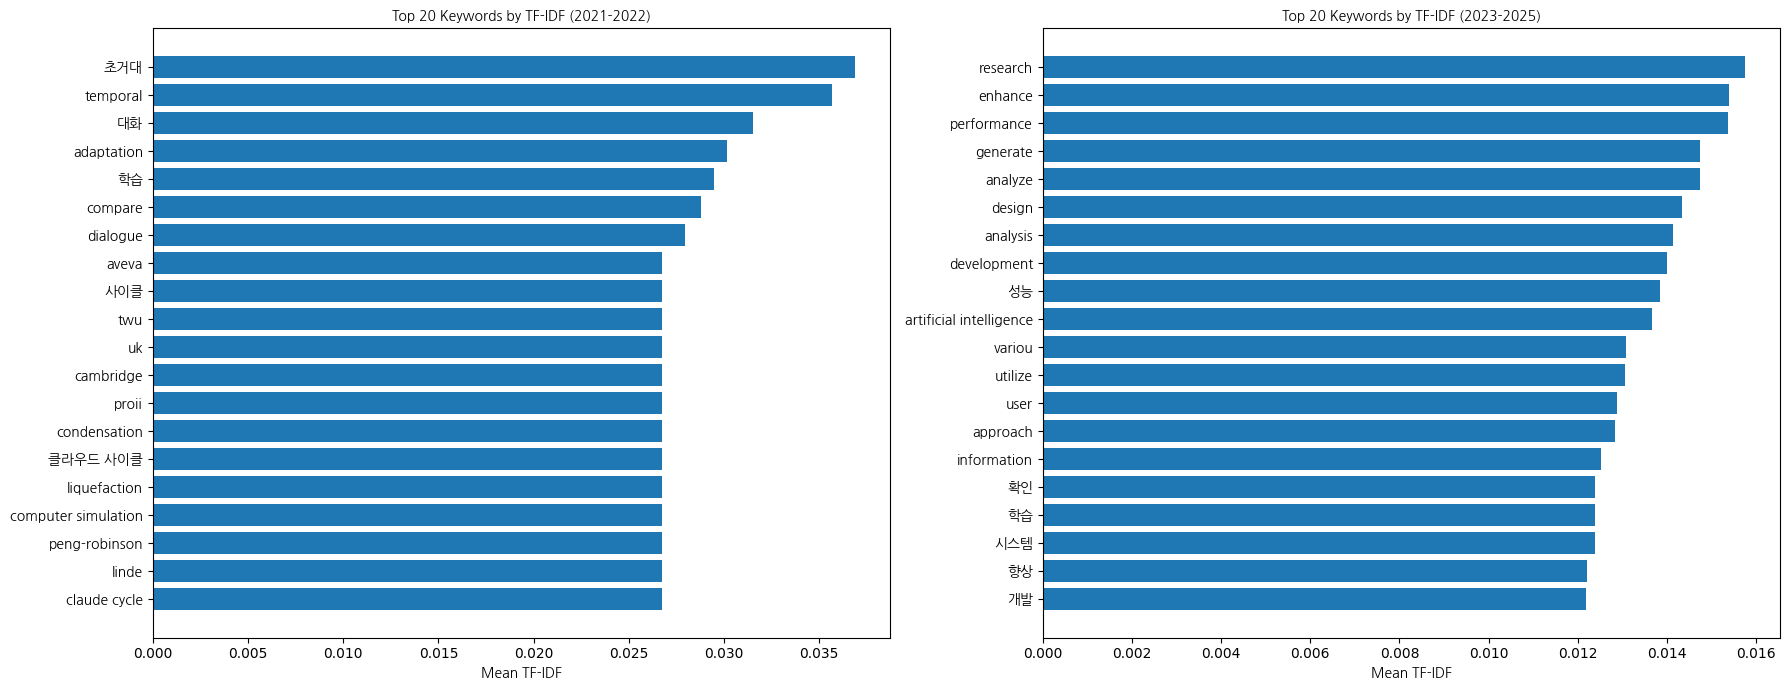

[2021-2022] TF-IDF Top 20 (after stopwords)


,keyword,tfidf,df,df_ratio,n_docs_period
1,초거대,0.036866,2,0.133333,15
3,temporal,0.035652,1,0.066667,15
4,대화,0.031496,2,0.133333,15
5,adaptation,0.030129,1,0.066667,15
6,학습,0.029481,5,0.333333,15
7,compare,0.028795,7,0.466667,15
8,dialogue,0.027965,1,0.066667,15
11,claude cycle,0.026756,2,0.133333,15
12,proii,0.026756,2,0.133333,15
13,condensation,0.026756,2,0.133333,15


[2023-2025] TF-IDF Top 20 (after stopwords)


,keyword,tfidf,df,df_ratio,n_docs_period
0,research,0.015748,242,0.301746,802
2,enhance,0.015392,242,0.301746,802
3,performance,0.015375,240,0.299252,802
6,generate,0.014747,204,0.254364,802
7,analyze,0.014745,227,0.283042,802
9,design,0.014326,192,0.239401,802
11,analysis,0.014136,216,0.269327,802
13,development,0.014010,196,0.244389,802
15,성능,0.013841,209,0.260599,802
16,artificial intelligence,0.013658,185,0.230673,802


In [59]:
TOPK_BAR = 20      # 막대그래프는 최종 20개
TOPK_POOL = 80    # 불용 제거 후에도 20개가 남도록 넉넉히 ...

STOPWORDS_VIS = { # 불용어
    "recent", "however", "show", "suggest", "verify",
    "complete", "use", "using", "used",
    "improve", "provide", "demonstrate",
    "various", "include", "system", "technology",
}

# 전/후 비교용 global vectorizer: 2021~2025 GenAI 문서 전체로 1회 fit
global_vec = fit_global_tfidf_vectorizer(df, 2021, 2025, min_df=2, max_df=0.8)

# 기간별 tf-idf pool 계
tfidf_pool_by_period = {}
for label, (y0, y1) in PERIODS.items():
    tfidf_pool_by_period[label] = compute_period_tfidf_topk_prefit(
        df, y0, y1, vectorizer=global_vec, top_k=TOPK_POOL
    )

# 기간별 df_ratio
df_ratio_by_period = {}
for label, (y0, y1) in PERIODS.items():
    df_ratio_by_period[label] = compute_period_df_ratio(df, y0, y1)

tfidf_df_ratio_by_period = {}
for label in PERIODS.keys():
    tfidf_df_ratio_by_period[label] = (
        tfidf_pool_by_period[label]
        .merge(df_ratio_by_period[label], on="keyword", how="left")
        .fillna({"df": 0, "df_ratio": 0.0})
    )

# 불용어 제거 후, 막대그래프/표용 Top20 재선정 (df_ratio 포함)
tfidf_bar_by_period = {}
for label, kw_df in tfidf_df_ratio_by_period.items():
    cleaned = kw_df[~kw_df["keyword"].isin(STOPWORDS_VIS)].copy()
    tfidf_bar_by_period[label] = cleaned.sort_values("tfidf", ascending=False).head(TOPK_BAR)


_fontprop = globals().get("font_prop", None)
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=False) # 막대그래프 (최종 Top20만)

for ax, (label, kw_df) in zip(axes, tfidf_bar_by_period.items()):
    plot_df = kw_df.sort_values("tfidf", ascending=True)  # 작은 값이 아래

    ax.barh(plot_df["keyword"], plot_df["tfidf"])
    ax.set_title(f"Top {TOPK_BAR} Keywords by TF-IDF ({label})",
                 fontproperties=_fontprop if _fontprop else None)
    ax.set_xlabel("Mean TF-IDF", fontproperties=_fontprop if _fontprop else None)

    if _fontprop:
        for tick in ax.get_yticklabels():
            tick.set_fontproperties(_fontprop)

plt.tight_layout()
plt.show()

# 막대그래프에 사용된 Top20 표로 보기
for label, kw_df in tfidf_bar_by_period.items():
    print("=" * 80)
    print(f"[{label}] TF-IDF Top {TOPK_BAR} (after stopwords)")
    print("=" * 80)
    display(kw_df)

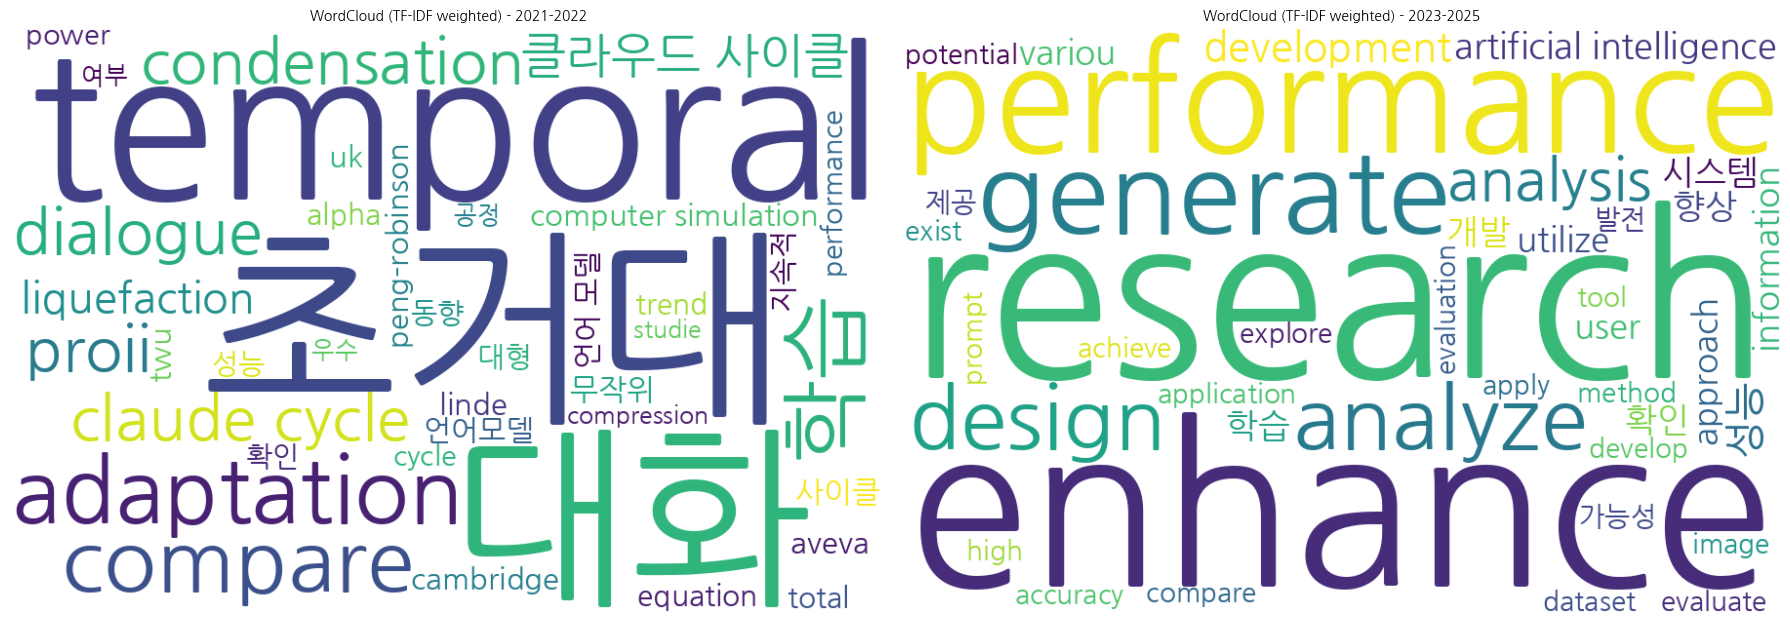

In [63]:
FONT_PATH_FOR_WORDCLOUD = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

def plot_wordcloud_from_tfidf(ax, kw_df: pd.DataFrame, title: str,
                              wc_topn: int = 120):
    tmp = kw_df[~kw_df["keyword"].isin(STOPWORDS_VIS)].copy()
    tmp = tmp.sort_values("tfidf", ascending=False).head(wc_topn)

    freq = dict(zip(tmp["keyword"], tmp["tfidf"]))

    wc = WordCloud(
        width=900,
        height=600,
        background_color="white",
        font_path=FONT_PATH_FOR_WORDCLOUD,
        max_words=wc_topn,
        collocations=False
    ).generate_from_frequencies(freq)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontproperties=_fontprop if _fontprop else None)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (label, kw_df_pool) in zip(axes, tfidf_pool_by_period.items()):
    plot_wordcloud_from_tfidf(ax, kw_df_pool, f"WordCloud (TF-IDF weighted) - {label}", wc_topn=40)

plt.tight_layout()
plt.show()